In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
print('imported')

imported


In [2]:
dirs = '/home/ab303el/Documents/virtual internship/CodeAlpha Internship/data/'
data = 'clean_data.csv'
data = dirs + data

In [3]:
df = pd.read_csv(data)

df.head(2)

,Country,Disaster_Type,Continent,Year,Category,Disaster_status
0,Indonesia,Earthquake,Asia,2026,Geophysical (Non-Climate),Non-Climate
1,Colombia,Earthquake,South America,2026,Geophysical (Non-Climate),Non-Climate


In [5]:
#  Pivot our data to get total counts per year for each disaster type
yearly_trends = pd.pivot_table(
    df, 
    values='Country', # Just a column to count
    index='Year', 
    columns='Disaster_Type', 
    aggfunc='count', 
    fill_value=0
)


In [7]:
# we Create a 26-Year Rolling Average to smooth out the noise
rolling_trends = yearly_trends.rolling(window=26).mean()

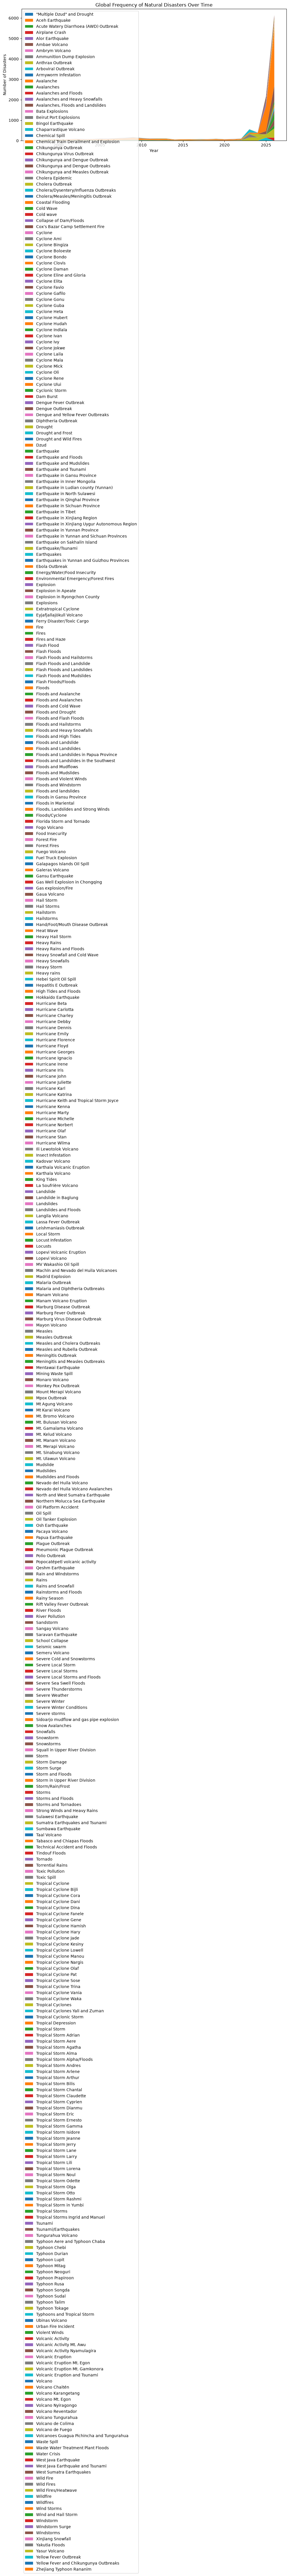

In [8]:
# Plotting a stacked area chart
plt.figure(figsize=(12, 6))
plt.stackplot(yearly_trends.index, yearly_trends.T, labels=yearly_trends.columns)
plt.title('Global Frequency of Natural Disasters Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Disasters')
plt.legend(loc='upper left')
plt.show()

we can see the frequency of each disaster over the last 26 years

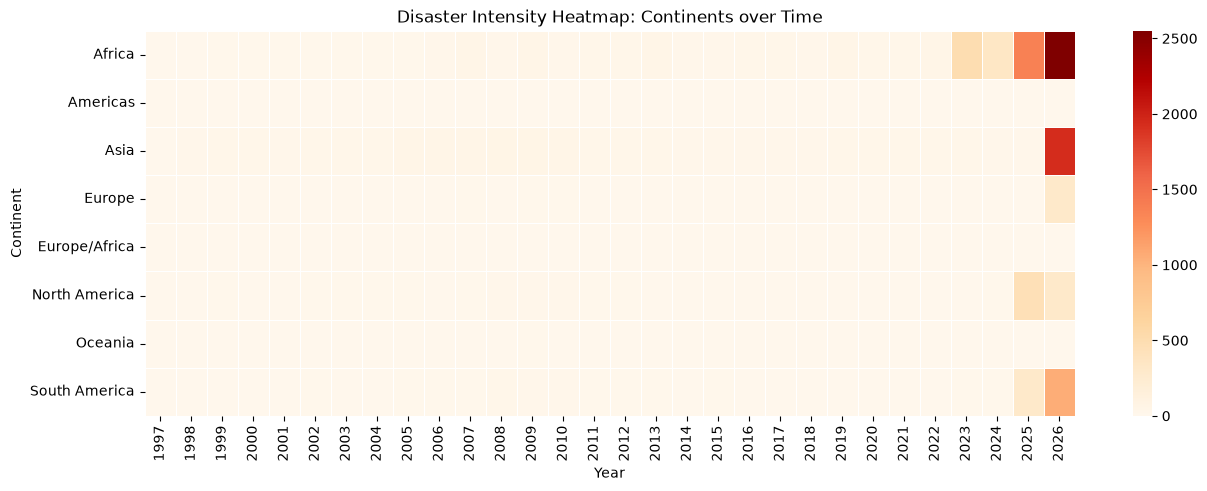

In [10]:
# Group by Year AND Continent
continent_year = pd.pivot_table(df, values='Country', index='Continent', columns='Year', aggfunc='count', fill_value=0)

plt.figure(figsize=(15, 5))
sns.heatmap(continent_year, cmap='OrRd', linewidths=0.5)
plt.title('Disaster Intensity Heatmap: Continents over Time')
plt.show()

from this heat map plot we can see africa is more frequently visited by disasters
and asia after that and south america third place and europe and oceania being the 
almost  disaster free

Categorize our disasters into Climate and Geophysical

In [11]:
climate_mapping = {
    'Flood': 'Climate-Driven',
    'Storm': 'Climate-Driven',
    'Drought': 'Climate-Driven',
    'Extreme temperature': 'Climate-Driven',
    'Wildfire': 'Climate-Driven',
    'Landslide': 'Climate-Driven',
    'Earthquake': 'Geophysical (Non-Climate)',
    'Volcanic activity': 'Geophysical (Non-Climate)',
    'Mass movement (dry)': 'Geophysical (Non-Climate)'
}

In [ ]:
# Apply mapping and create a new broad category column
df['Climate_category'] = df['Disaster_Type'].map(climate_mapping)

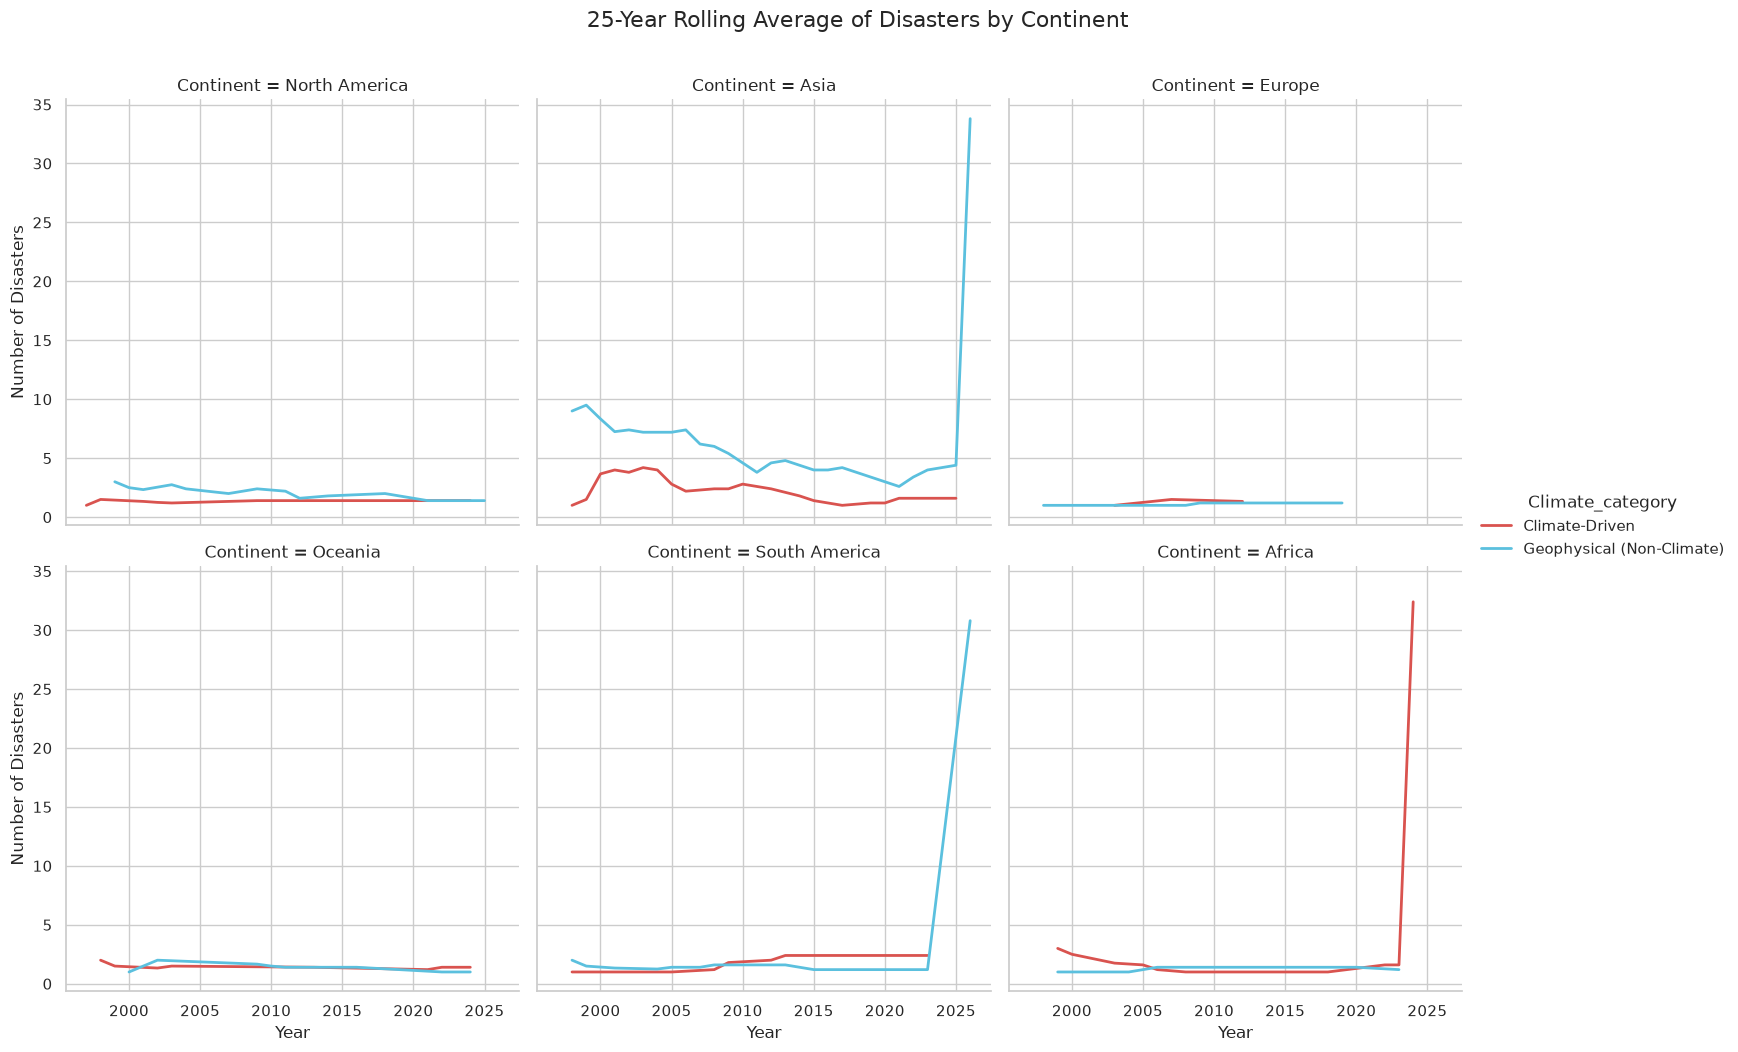

In [13]:
# Aggregate data: Count disasters per Year, Continent, and Category
trend_data = df.groupby(['Year', 'Continent', 'Climate_category']).size().reset_index(name='disaster_count')

# Apply a 5-year rolling average to smooth out the noise
trend_data['smoothed_count'] = trend_data.groupby(['Continent', 'Climate_category'])['disaster_count'].transform(lambda x: x.rolling(5, min_periods=1).mean())

# Create the Facet Grid for each continent and red for climate and blue for non-climate related
sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=trend_data, 
    x='Year', 
    y='smoothed_count', 
    hue='Climate_category', 
    col='Continent',     
    col_wrap=3,          
    kind='line', 
    linewidth=2,
    palette=['#d9534f', '#5bc0de'] 
)

g.fig.suptitle('25-Year Rolling Average of Disasters by Continent', y=1.05, fontsize=16)
g.set_axis_labels("Year", "Number of Disasters")
plt.show()

from our facet grid comparing climate and non-climate for each continent with color code
africa seems to be affected more extremely by climate related diasters more than others
and asia next in climate effects , and non-climate disasters to be extreme in asia and
south america, while both europe and oceania seem to be affected less than other continents

 Aggregate total historical counts

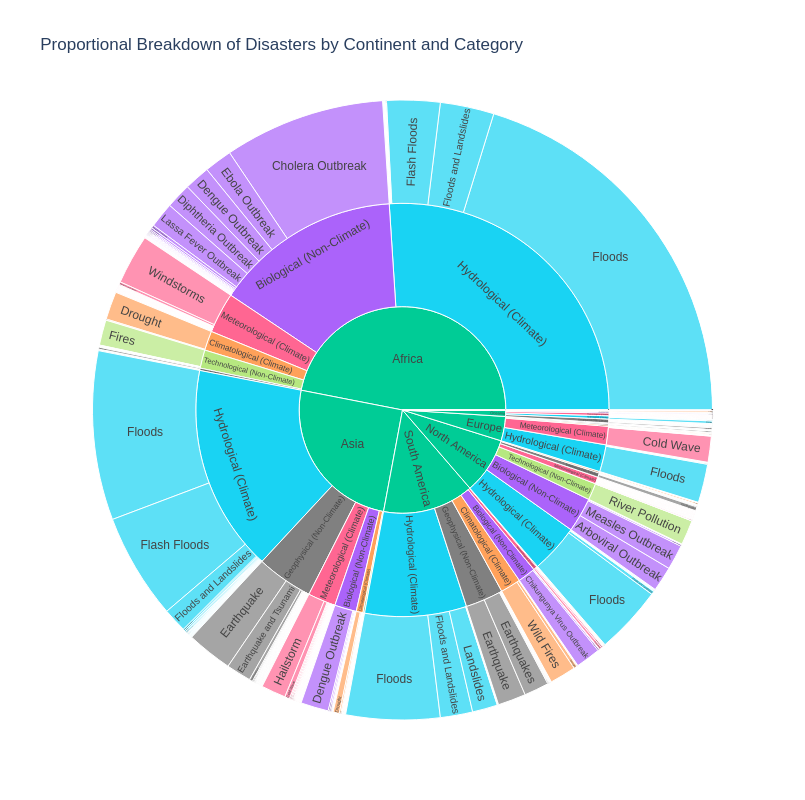

In [15]:
sunburst_data = df.groupby(['Continent', 'Category', 'Disaster_Type']).size().reset_index(name='count')

# Create an interactive Plotly chart
fig = px.sunburst(
    sunburst_data, 
    path=['Continent', 'Category', 'Disaster_Type'], 
    values='count',
    color='Category',
    color_discrete_map={'Climate-Driven': 'coral', 'Geophysical (Non-Climate)': 'gray'},
    title='Proportional Breakdown of Disasters by Continent and Category'
)

fig.update_layout(width=800, height=800)
fig.show() 

we get an interactive chart where we get a detailed infor for each continent 
and we can see flood seems to be the most frequent climate disaster happening
in each continent

 Create an 'Era' column based on the year

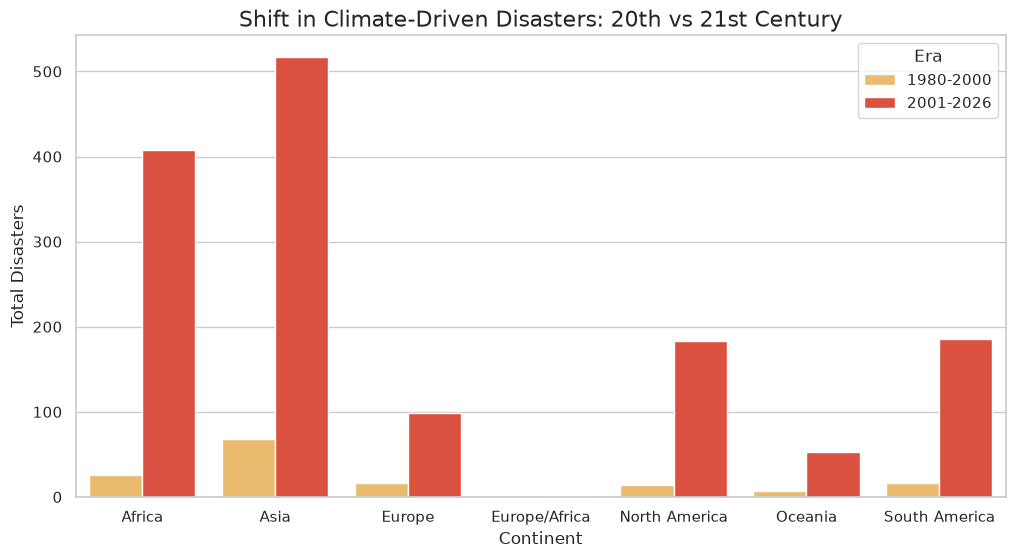

In [16]:
df['Era'] = pd.cut(df['Year'], bins=[1980, 2000, 2020], labels=['1980-2000', '2001-2026'])

# we Filter our data for just Climate-Driven disasters
climate_only = df[df['Disaster_status'] == 'Climate-Driven']

# Count occurrences
era_data = climate_only.groupby(['Continent', 'Era']).size().reset_index(name='total_climate_disasters')

# Plot Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=era_data, 
    x='Continent', 
    y='total_climate_disasters', 
    hue='Era', 
    palette='YlOrRd'
)

plt.title('Shift in Climate-Driven Disasters: 20th vs 21st Century', fontsize=16)
plt.ylabel('Total Disasters')
plt.xlabel('Continent')
plt.show()

our bar chart shows each continents dual comarison of each disaster types 
frequency

Count total yearly disasters per continent and category

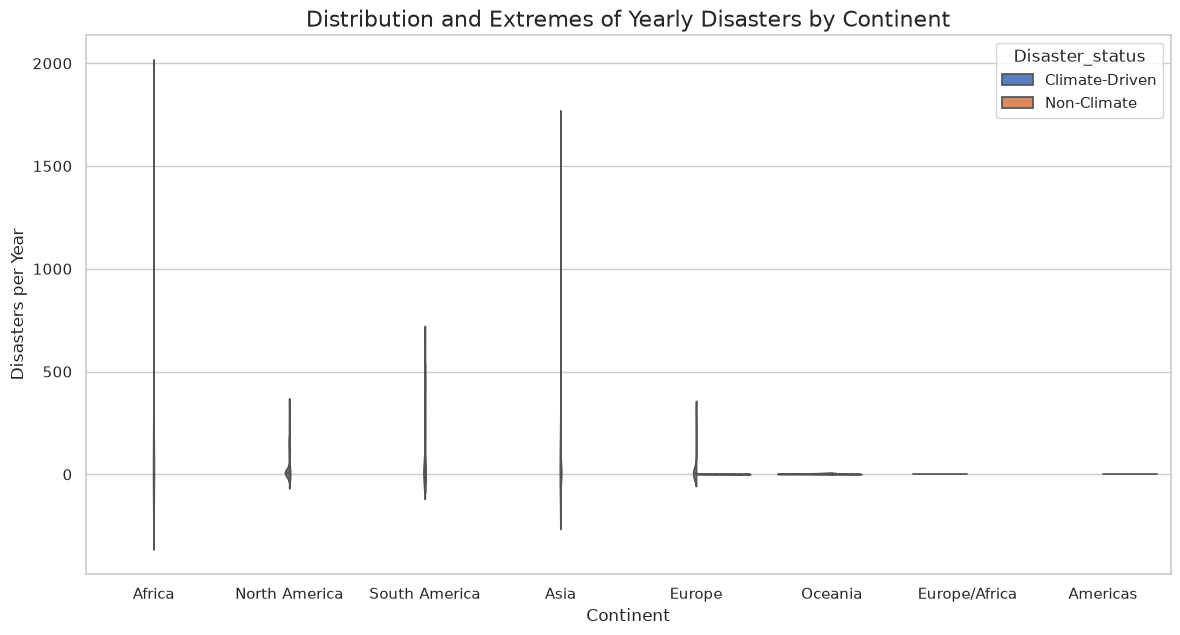

In [17]:
yearly_continent = df.groupby(['Year', 'Continent', 'Disaster_status']).size().reset_index(name='yearly_count')

plt.figure(figsize=(14, 7))
sns.violinplot(
    data=yearly_continent, 
    x='Continent', 
    y='yearly_count', 
    hue='Disaster_status', 
    split=True, 
    inner="quartile",
    palette="muted"
)

plt.title('Distribution and Extremes of Yearly Disasters by Continent', fontsize=16)
plt.ylabel('Disasters per Year')
plt.xlabel('Continent')
plt.show()

Create a pivot table

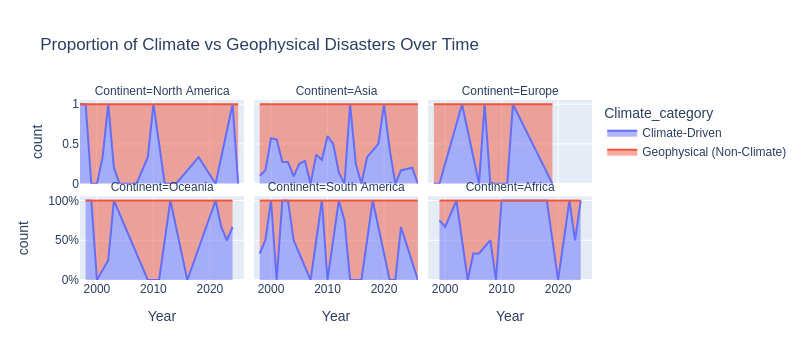

In [19]:
# Year as index, Continents/Categories as columns
prop_data = df.groupby(['Year', 'Continent', 'Climate_category']).size().unstack(fill_value=0).reset_index()

# Calculate percentages (Climate vs Non-Climate)
prop_data['Total'] = prop_data['Climate-Driven'] + prop_data['Geophysical (Non-Climate)']
prop_data['Climate_Pct'] = (prop_data['Climate-Driven'] / prop_data['Total']) * 100
prop_data['Geo_Pct'] = (prop_data['Geophysical (Non-Climate)'] / prop_data['Total']) * 100

# Plotting with Plotly for easier 100% stacking by continent
fig = px.area(
    df.groupby(['Year', 'Continent', 'Climate_category']).size().reset_index(name='count'), 
    x="Year", 
    y="count", 
    color="Climate_category", 
    facet_col="Continent", 
    facet_col_wrap=3,
    groupnorm='fraction', 
    title="Proportion of Climate vs Geophysical Disasters Over Time"
)

fig.update_layout(yaxis_tickformat='.0%')
fig.show()

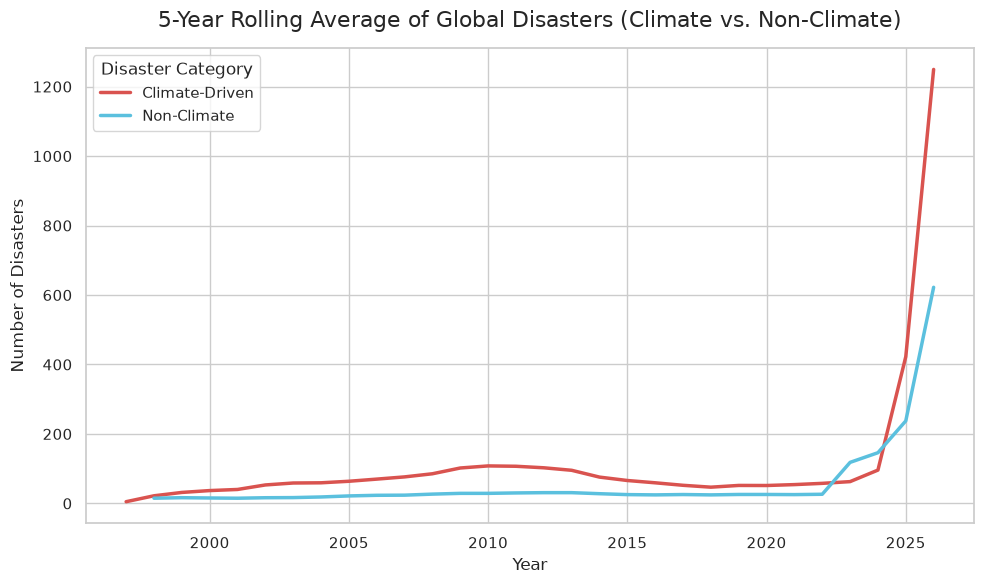

In [20]:
#  Aggregate data: Count disasters per Year and Category ONLY (ignoring Continent)
world_trend_data = df.groupby(['Year', 'Disaster_status']).size().reset_index(name='disaster_count')

#  Apply a 5-year rolling average to smooth out the noise
# (Note: Grouping only by Climate_category now)
world_trend_data['smoothed_count'] = world_trend_data.groupby('Disaster_status')['disaster_count'].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)

#   single global chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6)) 

sns.lineplot(
    data=world_trend_data, 
    x='Year', 
    y='smoothed_count', 
    hue='Disaster_status', 
    linewidth=2.5,
    palette=['#d9534f', '#5bc0de'] # Red for climate, Blue for non-climate
)

#  Formatting and Labels
plt.title('5-Year Rolling Average of Global Disasters (Climate vs. Non-Climate)', fontsize=16, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Disasters", fontsize=12)
plt.legend(title='Disaster Category', frameon=True)

plt.tight_layout()
plt.show()

we can see overall climate related disasters are happening more frequently 
over the past 25 years 

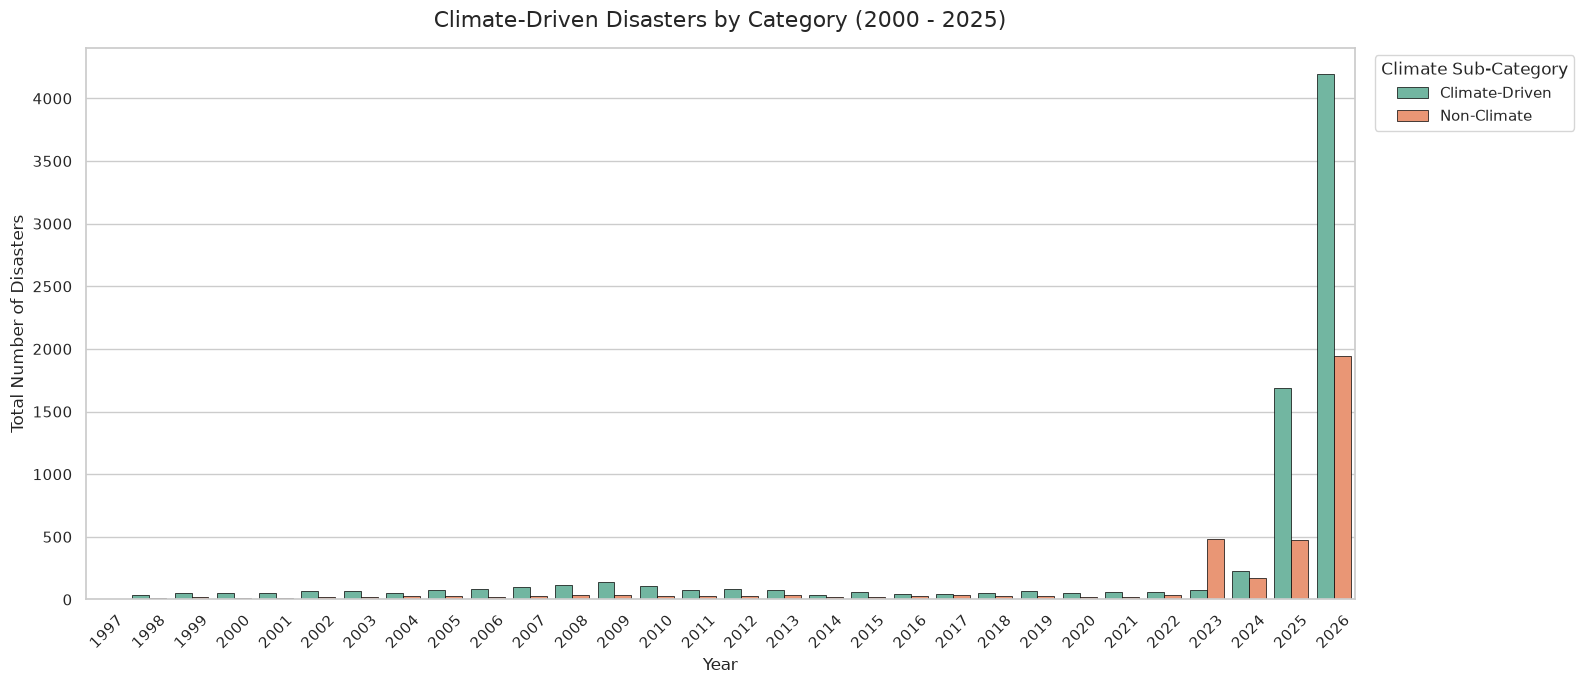

In [24]:
#  Aggregate data by Year and Category
yearly_counts = df.groupby(['Year', 'Disaster_status']).size().reset_index(name='disaster_count')

#  Create the standard grouped bar chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 7))

sns.barplot(
    data=yearly_counts,
    x='Year',
    y='disaster_count',
    hue='Disaster_status',
    palette='Set2',       
    edgecolor='black',   
    linewidth=0.5
)

#  Formatting and Labels
plt.title('Climate-Driven Disasters by Category (2000 - 2025)', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Number of Disasters', fontsize=12)
plt.xticks(rotation=45)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Climate Sub-Category', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

the final conclusion we get from this data analysis is africa as a continent is heavily affected by climated 
change more than any other continents 